In [1]:
# Import libraries

import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mafese import Data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression  # Just for evaluating during feature selection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, roc_curve

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
# Load Dataset
df = pd.read_csv('creditcard.csv')

# Optional: Drop 'id' column if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Shuffle the data to mix Class 0 and Class 1
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare features and labels
X = df.drop('Class', axis=1)  # Features
y = df['Class']               # Labels

# x_data = X[:100001]
# y_data = y[:100001]


# Assuming X, y are your original dataset and labels
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

# Initialize mafese Data object
data = Data(X, y)

# Split the data
# (mafese automatically splits into training and testing sets)
data.split_train_test(test_size=0.3, random_state=42, inplace=True, stratify=y)  # You can adjust test_size and seed

# Scale the features
data.X_train, scaler_X = data.scale(data.X_train, scaling_methods=("standard", "minmax"))
data.X_test = scaler_X.transform(data.X_test)

# Encode the labels
data.y_train, scaler_y = data.encode_label(data.y_train)
data.y_test = scaler_y.transform(data.y_test)

# Print data shapes
print(f"Training Features Shape: {data.X_train.shape}")
print(f"Training Labels Shape: {data.y_train.shape}")
print(f"Testing Features Shape: {data.X_test.shape}")
print(f"Testing Labels Shape: {data.y_test.shape}")

Training Features Shape: (398041, 30)
Training Labels Shape: (398041,)
Testing Features Shape: (170589, 30)
Testing Labels Shape: (170589,)


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



In [3]:
data.y_test

array([1, 0, 0, ..., 1, 0, 0])

## Exploratory Data Analysis

In [4]:
# load the dataset (read the CSV file)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
1,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
2,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
3,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
4,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [5]:
# Show the dataset information, including data types and missing values
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.176758e-15,3.384475e-16,-1.399495e-15,2.094652e-15,1.006511e-15,1.495446e-15,-5.633807e-16,1.141630e-16,-2.411994e-15,...,1.616146e-16,-3.510464e-16,2.630603e-16,4.473016e-15,5.146818e-16,1.685202e-15,-3.655912e-16,-1.227702e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

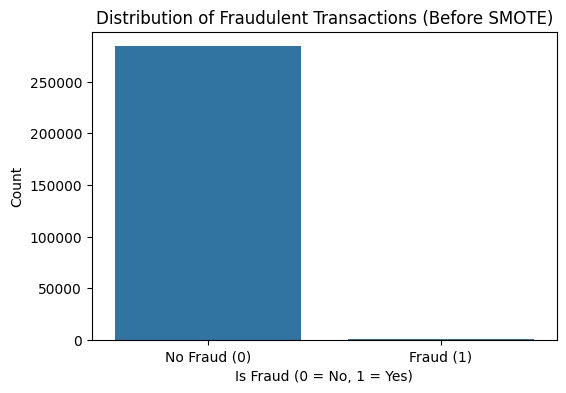

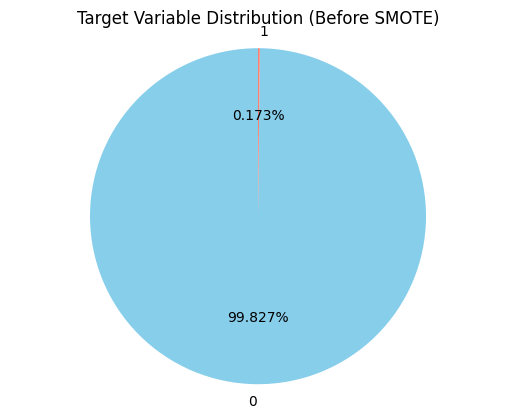

In [7]:
# Plot countplot before SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent Transactions (Before SMOTE)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Fraud (0)', 'Fraud (1)'])
plt.show()

# Plot pie chart before SMOTE
labels = [0, 1]
sizes = df['Class'].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%', startangle=90, colors=['skyblue', 'salmon'])
ax.set_title('Target Variable Distribution (Before SMOTE)')
ax.axis('equal')
plt.show()

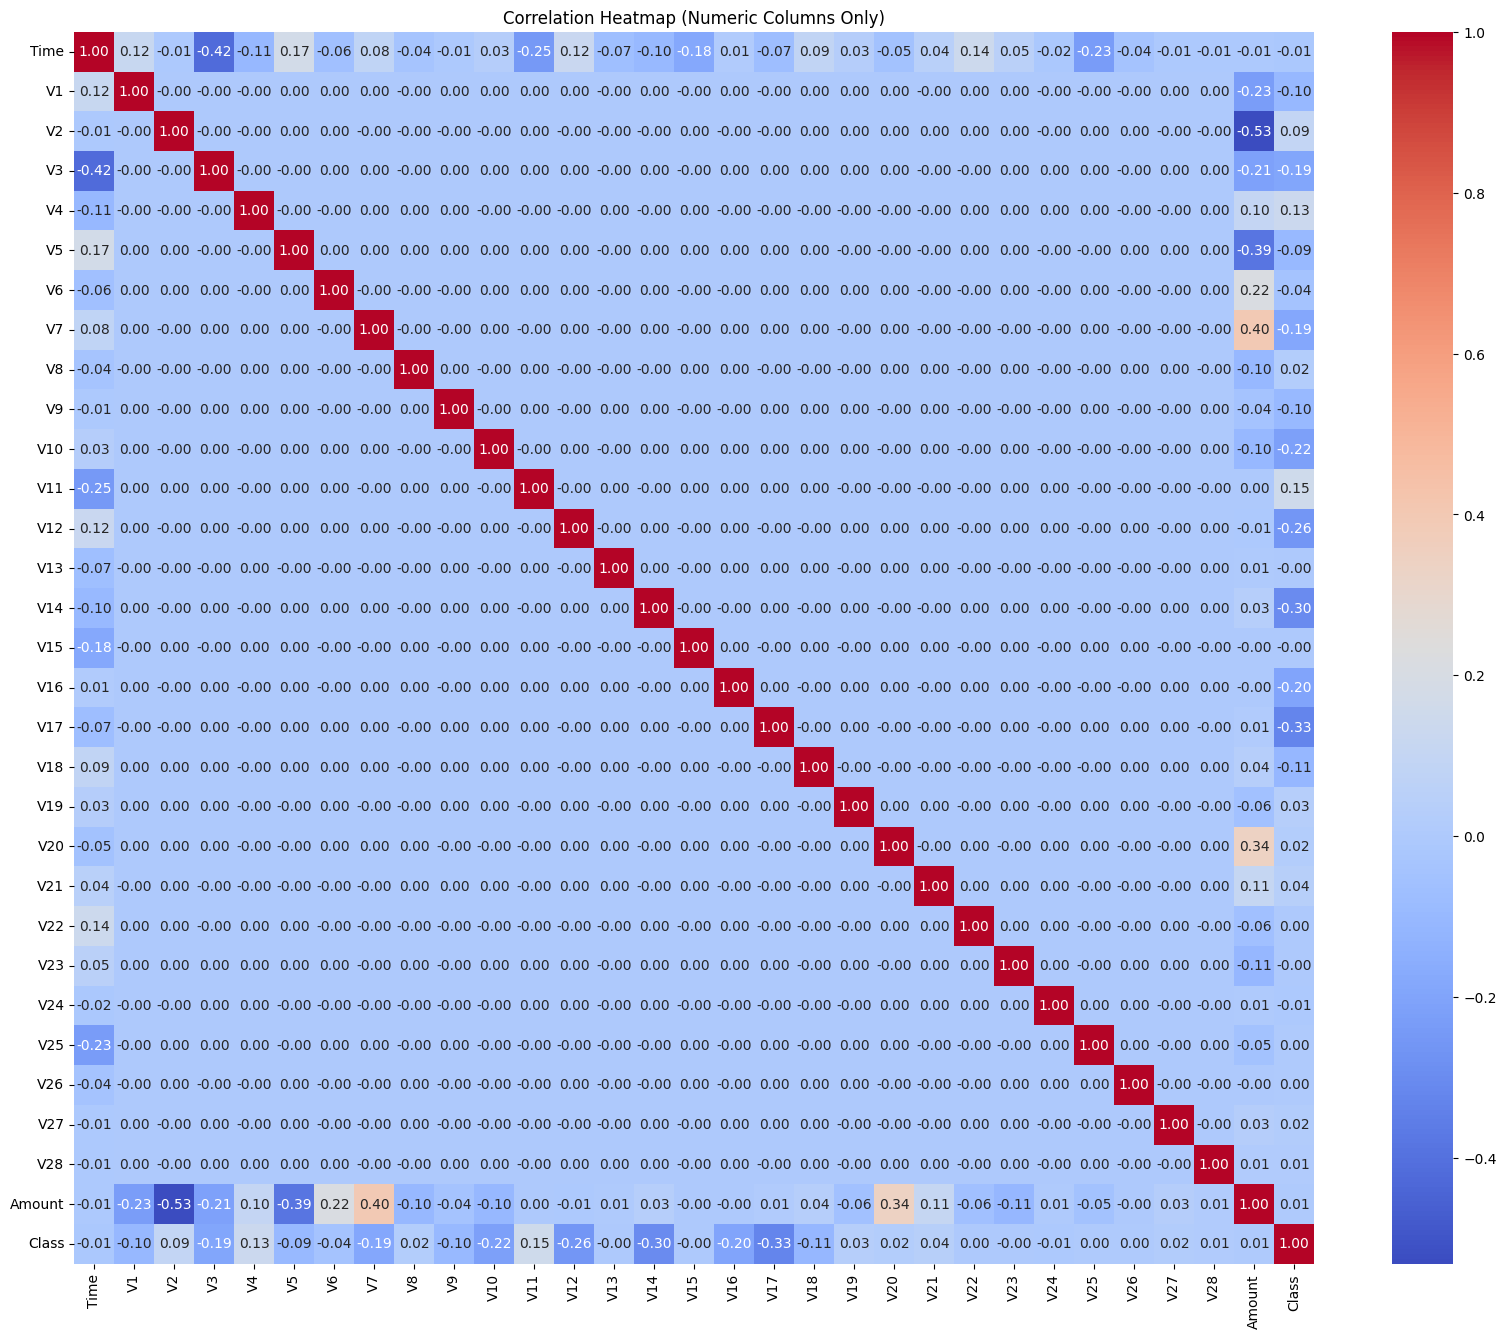

In [8]:
# Select only numeric columns for correlation analysis
numeric_data = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

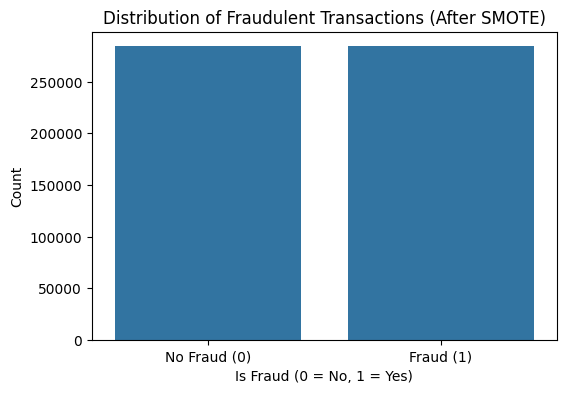

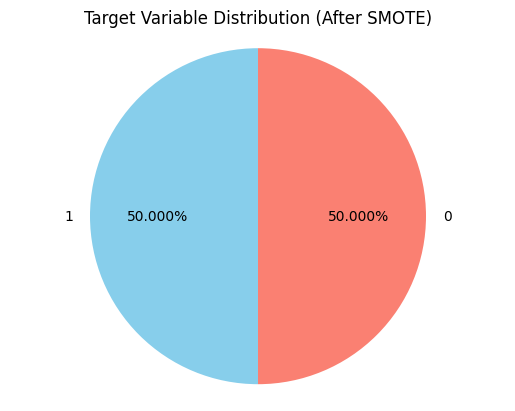

In [9]:
# Combine resampled X and y for plotting
df_smote = pd.DataFrame(X)
df_smote['Class'] = y

# Plot countplot after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_smote)
plt.title('Distribution of Fraudulent Transactions (After SMOTE)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Fraud (0)', 'Fraud (1)'])
plt.show()

# Plot pie chart after SMOTE
labels = df_smote['Class'].unique()
sizes = df_smote['Class'].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%', startangle=90, colors=['skyblue', 'salmon'])
ax.set_title('Target Variable Distribution (After SMOTE)')
ax.axis('equal')
plt.show()

In [10]:
data.X_train

array([[8.96228053e-01, 9.58249691e-01, 8.10077506e-01, ...,
        4.79297158e-01, 2.09685007e-01, 1.70369468e-04],
       [3.91844341e-01, 9.37832585e-01, 7.76727332e-01, ...,
        4.71965080e-01, 2.09773532e-01, 1.52621037e-03],
       [3.94743848e-01, 7.34166626e-01, 9.02197080e-01, ...,
        5.06394689e-01, 2.25764445e-01, 5.08736791e-05],
       ...,
       [9.12198764e-01, 9.42830961e-01, 7.79872985e-01, ...,
        4.13958233e-01, 2.03479987e-01, 7.60561503e-04],
       [1.99493020e-01, 9.47293165e-01, 7.66689137e-01, ...,
        4.48576983e-01, 2.03428331e-01, 5.08736791e-04],
       [9.25810820e-01, 9.87303106e-01, 7.66793501e-01, ...,
        4.47068615e-01, 2.03446489e-01, 7.66310229e-03]])

In [11]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,41505.000000,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.190000
1,44261.000000,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.120000
2,35484.000000,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.000000
3,167123.000000,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.500000
4,168473.000000,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.890000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,143437.956050,-5.228669,0.396932,-5.399236,2.429005,0.685502,-1.993632,-5.809312,-0.857583,-2.837022,...,-0.397444,-0.633144,0.502355,-1.103368,0.171941,0.223427,-0.691607,0.579763,-0.170173,8.813198
568626,17909.811294,-7.208976,6.073354,-13.211000,8.913877,-8.776440,-0.797832,-13.041688,3.890206,-4.763769,...,-1.061339,1.153710,0.109778,-5.019806,-0.304459,-2.526048,0.120609,1.323421,-0.343598,896.347059
568627,93858.497438,-9.849055,6.808072,-15.959905,8.336749,-9.744518,-4.145458,-13.680522,6.696686,-3.804534,...,-0.404101,2.533295,0.209838,-0.700932,0.396402,0.020743,-0.063359,-1.194016,-0.237683,70.895030
568628,133012.404255,-1.079648,-1.919355,-5.861797,3.052687,-0.670396,-1.655632,1.488726,-0.605605,-1.557237,...,2.449811,1.195887,0.165804,-1.323405,-0.309850,0.669394,-0.269418,0.179233,0.335163,1201.492884


## Initializing The Enhanced BBOA Algorithm and Feature Selection Model

In [12]:
# ------------ Updated Enhanced BBOA Feature Selector ---------------- #

class EnhancedBBOAFeatureSelector:
    def __init__(self,
                 n_agents=20,
                 max_iter=30,
                 initial_exploration_rate=0.5,
                 r_min=0.1,
                 r_max=1.0,
                 boundaries=(0, 1),
                 classifier=None,
                 cv_folds=5,
                 save_dir="./enhanced_bboa_results",
                 random_state=None,
                 verbose=True,
                 plot_convergence=True):
        
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.initial_exploration_rate = initial_exploration_rate
        self.r_min = r_min
        self.r_max = r_max
        self.boundaries = boundaries
        self.classifier = classifier
        self.cv_folds = cv_folds
        self.save_dir = save_dir
        self.random_state = random_state
        self.verbose = verbose

        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        self.history = []

    def _initialize_population(self, dim):
        return np.random.uniform(self.boundaries[0], self.boundaries[1], (self.n_agents, dim))

    def _evaluate_fitness(self, population, X, y):
        fitness = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            mask = population[i] > 0.5
            if np.sum(mask) == 0:
                fitness[i] = np.inf  # Penalize invalid solutions
                continue

            X_selected = X[:, mask]
            scores = cross_val_score(self.classifier, X_selected, y, cv=self.cv_folds)
            fitness[i] = 1.0 - np.mean(scores)  # Lower fitness is better
        return fitness

    def _calculate_diversity(self, population):
        return np.mean(np.std(population, axis=0))

    def _select_best_and_worst(self, population, fitness):
        best_idx = np.argmin(fitness)
        worst_idx = np.argmax(fitness)
        return population[best_idx], population[worst_idx]

    def _enhance_exploration(self, population, best_bear, worst_bear, alpha_k, r_k, theta_k):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            rand_vector = np.random.uniform(-1, 1, size=population.shape[1])
            if 0 < theta_k <= 1/3:
                new_population[i] += alpha_k * rand_vector * r_k
            elif 1/3 < theta_k <= 2/3:
                new_population[i] += (alpha_k / 2) * rand_vector * r_k
            else:
                new_population[i] += (alpha_k / 5) * rand_vector * r_k

            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def _adaptive_sniffing(self, population, fitness, diversity, diversity_threshold=0.1):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            mate_idx = np.random.choice([idx for idx in range(self.n_agents) if idx != i])
            if diversity < diversity_threshold:
                if fitness[i] > fitness[mate_idx]:
                    new_population[i] = (population[i] + population[mate_idx]) / 2
            else:
                rand_factor = np.random.uniform(0, 1)
                new_population[i] = rand_factor * population[i] + (1 - rand_factor) * population[mate_idx]
            
            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def fit(self, X, y):
        """
        Fit the Enhanced BBOA algorithm to select features.
        """
        dim = X.shape[1]
        P = self._initialize_population(dim)
        fitness = self._evaluate_fitness(P, X, y)
    
        f_best = np.min(fitness)
        P_best = P[np.argmin(fitness)]
    
        for k in range(1, self.max_iter + 1):
            start_time = time.time()  # Start timing the epoch
            theta_k = k / self.max_iter
            alpha_k = self.initial_exploration_rate * (1 - theta_k)
            r_k = self.r_min + (self.r_max - self.r_min) * (1 - theta_k)
    
            # Step 1: Enhance Exploration
            best_bear, worst_bear = self._select_best_and_worst(P, fitness)
            new_P = self._enhance_exploration(P, best_bear, worst_bear, alpha_k, r_k, theta_k)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 2: Greedy Replacement after Exploration
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:  # lower fitness is better
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 3: Update Best
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            # Step 4: Calculate Diversity
            diversity = self._calculate_diversity(P)
    
            # Step 5: Adaptive Sniffing
            new_P = self._adaptive_sniffing(P, fitness, diversity)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 6: Greedy Replacement after Sniffing
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 7: Update Best Again
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            self.history.append(f_best)

            # Calculate elapsed time
            elapsed_time = time.time() - start_time
    
            if self.verbose:
                print(f"Iteration {k}/{self.max_iter}, Best Fitness: {f_best:.6f}, Diversity: {diversity:.6f}, Time: {elapsed_time:.2f}s")
    
        self.best_fitness = f_best
        self.best_agent = P_best
        self._save_best_agent()
    
        if self.plot_convergence:
            self.plot_convergence()


    def transform(self, X):
        """
        Transform the dataset using the selected features.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features only.
        """
        if self.best_agent is None:
            raise Exception("Model has not been fitted yet. Call `fit` first.")
            
        mask = self.best_agent > 0.5
        return X[:, mask]

    def fit_transform(self, X, y):
        """
        Fit the model and transform the dataset.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features.
        """
        self.fit(X, y)
        return self.transform(X)

    def _save_best_agent(self):
        np.save(os.path.join(self.save_dir, "best_agent.npy"), self.best_agent)
        summary = {
            "selected_features_count": int(np.sum(self.best_agent > 0.5)),
            "total_features": int(len(self.best_agent)),
            "best_fitness_score": float(self.best_fitness),
            "cv_folds": self.cv_folds
        }
        with open(os.path.join(self.save_dir, "summary.json"), "w") as f:
            json.dump(summary, f, indent=4)

    def get_selected_indices(self):
        return np.where(self.best_agent > 0.5)[0]

    def plot_convergence(self):
        """
        Plot the convergence curve of the fitness over iterations.
        """
        plt.figure(figsize=(8, 5))
        plt.plot(self.history, label="Best Fitness")
        plt.xlabel("Iteration")
        plt.ylabel("Fitness")
        plt.title("Convergence Curve")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(self.save_dir, "fitness_curve.png"))
        plt.show()

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

Iteration 1/30, Best Fitness: 0.027809, Diversity: 0.315515, Time: 124.96s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

Iteration 2/30, Best Fitness: 0.027809, Diversity: 0.296698, Time: 118.55s
Iteration 3/30, Best Fitness: 0.027683, Diversity: 0.264827, Time: 107.98s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

...

Iteration 28/30, Best Fitness: 0.024151, Diversity: 0.096834, Time: 172.01s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

Iteration 29/30, Best Fitness: 0.024151, Diversity: 0.093850, Time: 171.52s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

Iteration 30/30, Best Fitness: 0.024151, Diversity: 0.093576, Time: 168.82s


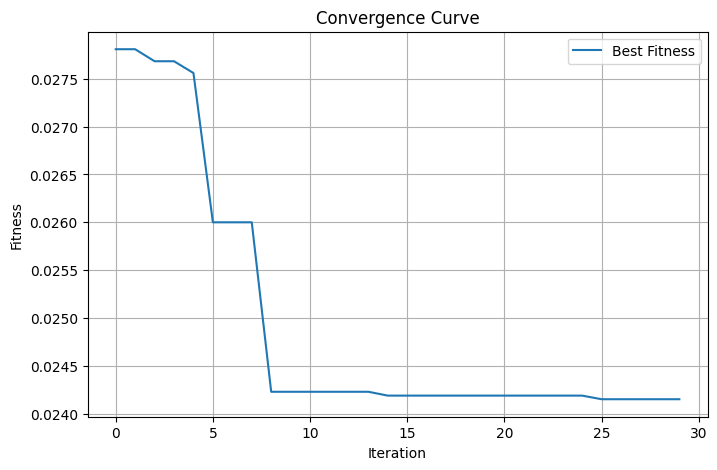

Original features: 30
Selected features: 23


In [13]:
# Initialize Enhanced BBOA Feature Selector
enhanced_bboa_selector = EnhancedBBOAFeatureSelector(
    n_agents=20,
    max_iter=30,
    initial_exploration_rate=0.5,
    classifier=LogisticRegression(),
    cv_folds=5,
    save_dir="./enhanced_bboa_results",
    random_state=42
)

# Fit and transform your data
X_train_selected = enhanced_bboa_selector.fit_transform(data.X_train, data.y_train)

# Reduce X_test as well
selected_indices = enhanced_bboa_selector.get_selected_indices()
X_test_selected = data.X_test[:, selected_indices]

print(f"Original features: {data.X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

In [14]:
X_train_selected.shape[1]

23

In [15]:
X_test_selected

array([[8.79331731e-01, 8.67855738e-01, 7.24182999e-01, ...,
        5.33953310e-01, 2.36316802e-01, 6.58881890e-06],
       [9.22315207e-01, 9.92772467e-01, 8.67391153e-01, ...,
        5.69879808e-01, 2.02958771e-01, 3.21012915e-03],
       [2.06374285e-01, 9.02688783e-01, 9.11929966e-01, ...,
        5.28585019e-01, 1.95532125e-01, 1.45274878e-02],
       ...,
       [2.38485925e-01, 8.07962724e-01, 6.36154222e-01, ...,
        5.90643145e-01, 2.05584713e-01, 5.05488118e-05],
       [7.42285344e-01, 9.66634413e-01, 8.94345904e-01, ...,
        4.56573570e-01, 2.12460658e-01, 1.85027571e-03],
       [2.78607311e-01, 9.74529608e-01, 8.83478206e-01, ...,
        5.88996725e-01, 2.04374994e-01, 7.77858554e-03]])

In [16]:
# --------- Simple SNN Model for Classification ------------- #

# -------- Surrogate Function --------
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # surrogate gradient: d(ReLU)/dx (approximate)
        surrogate_grad = torch.sigmoid(5 * input) * (1 - torch.sigmoid(5 * input))
        return grad_input * surrogate_grad

surrogate_spike_fn = SurrogateSpike.apply

# -------- Updated SNNLayer --------
class SNNLayer(nn.Module):
    def __init__(self, in_features, out_features, threshold=1.0, decay=0.9):
        super(SNNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.decay = decay
        self.mem = None

    def forward(self, x):
        if self.mem is None:
            self.mem = torch.zeros(x.size(0), self.fc.out_features, device=x.device)

        current = self.fc(x)
        self.mem = self.mem * self.decay + current
        spike = surrogate_spike_fn(self.mem - self.threshold)
        self.mem = self.mem * (1 - spike)  # reset after spike
        return spike

    def reset(self):
        self.mem = None

# -------- Updated SNNClassifier --------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, threshold=1.0):
        super(SNNClassifier, self).__init__()
        self.snn1 = SNNLayer(input_dim, hidden_dim, threshold=threshold)
        self.snn2 = SNNLayer(hidden_dim, output_dim, threshold=threshold)

    def forward(self, x, time_steps=20):
        out_spikes = torch.zeros(x.size(0), self.snn2.fc.out_features, device=x.device)
        for t in range(time_steps):
            spike1 = self.snn1(x)
            spike2 = self.snn2(spike1)
            out_spikes += spike2
        return out_spikes  # output spike counts (higher means more confident)

    def reset(self):
        self.snn1.reset()
        self.snn2.reset()

# -------- Updated SNNTrainer --------
class SNNTrainer:
    def __init__(self, model, lr=1e-3, epochs=30, batch_size=32, device=None):
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.losses = []

    def fit(self, X_train, y_train):
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.epochs):
            
            start_time = time.time()
            
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                self.model.reset()
                out = self.model(xb)

                loss = criterion(out, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(loader)
            self.losses.append(avg_epoch_loss)

             # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_epoch_loss:.4f}, Time: {elapsed_time:.2f}s")

    def plot_training_loss(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.losses, label="Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def evaluate(self, X_test, y_test):
        self.model.eval()
        X_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(self.device)
    
        self.model.reset()
        out = self.model(X_test)  # raw logits or probabilities
        preds = torch.argmax(out, dim=1)
    
        y_true = y_test.cpu().numpy()
        y_pred = preds.cpu().numpy()
    
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
    
        # MCC
        mcc = matthews_corrcoef(y_true, y_pred)
    
        # AUC-ROC Score (binary or one-vs-rest)
        if out.shape[1] == 2:
            probs = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            auc_roc = roc_auc_score(y_true, probs)
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_true, probs)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.4f}')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            auc_roc = roc_auc_score(y_true, out.detach().cpu().numpy(), multi_class='ovr', average='weighted')
    
        # Print Metrics
        print("\nClassification Report:\n", classification_report(y_true, y_pred))
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MCC:", mcc)
        print("AUC-ROC Score:", auc_roc)
    
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
        return acc, precision, recall, f1, mcc, auc_roc

    def save_model(self, path="./snn_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load_model(self, path="./snn_model.pth"):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

Epoch 1/30, Loss: 0.0951, Time: 53.72s
Epoch 2/30, Loss: 0.0746, Time: 51.86s
Epoch 3/30, Loss: 0.0678, Time: 52.40s
Epoch 4/30, Loss: 0.0623, Time: 52.24s
Epoch 5/30, Loss: 0.0638, Time: 53.88s
Epoch 6/30, Loss: 0.0626, Time: 52.35s
Epoch 7/30, Loss: 0.0626, Time: 52.98s
Epoch 8/30, Loss: 0.0691, Time: 53.08s
Epoch 9/30, Loss: 0.0644, Time: 52.88s
Epoch 10/30, Loss: 0.0599, Time: 52.60s
Epoch 11/30, Loss: 0.0579, Time: 52.69s
Epoch 12/30, Loss: 0.0594, Time: 52.41s
Epoch 13/30, Loss: 0.0535, Time: 52.06s
Epoch 14/30, Loss: 0.0498, Time: 52.01s
Epoch 15/30, Loss: 0.0506, Time: 52.47s
Epoch 16/30, Loss: 0.0490, Time: 52.04s
Epoch 17/30, Loss: 0.0540, Time: 51.75s
Epoch 18/30, Loss: 0.0596, Time: 51.84s
Epoch 19/30, Loss: 0.0578, Time: 51.81s
Epoch 20/30, Loss: 0.0543, Time: 51.78s
Epoch 21/30, Loss: 0.0540, Time: 51.86s
Epoch 22/30, Loss: 0.0524, Time: 51.89s
Epoch 23/30, Loss: 0.0564, Time: 51.75s
Epoch 24/30, Loss: 0.0499, Time: 51.78s
Epoch 25/30, Loss: 0.0496, Time: 51.79s
Epoch 26/

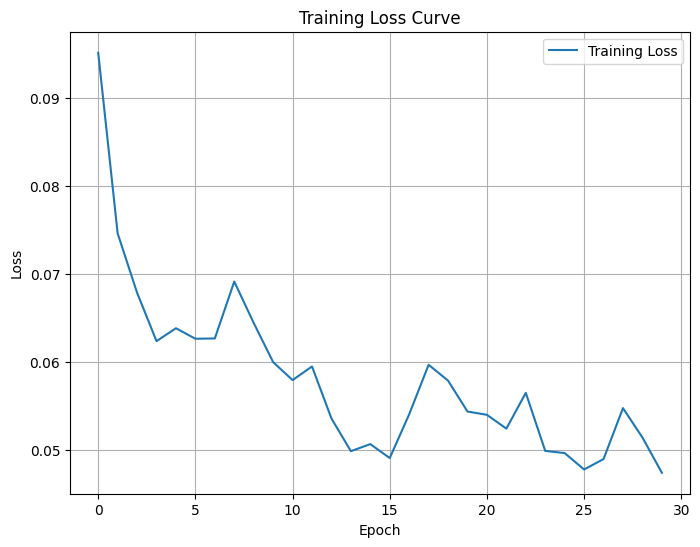

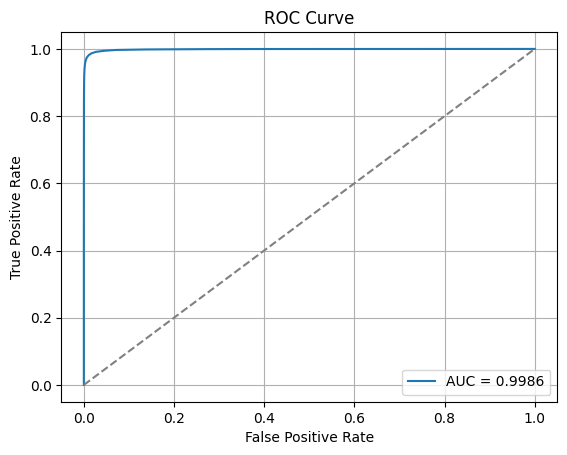


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     85295
           1       0.99      0.98      0.99     85294

    accuracy                           0.99    170589
   macro avg       0.99      0.99      0.99    170589
weighted avg       0.99      0.99      0.99    170589

Accuracy: 0.9853214451107632
Precision: 0.9853494576455567
Recall: 0.9853214451107632
F1 Score: 0.9853212329782471
MCC: 0.9706709016973754
AUC-ROC Score: 0.9986272085627004


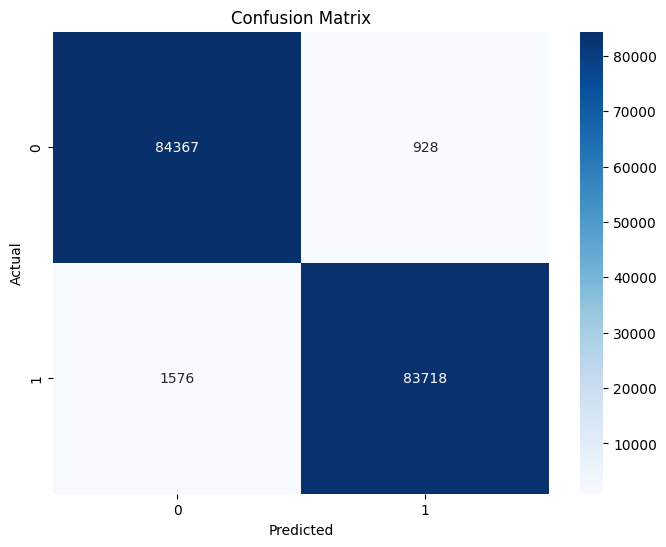

In [17]:
# Initialize
input_dim = X_train_selected.shape[1]
hidden_dim = 128
output_dim = len(np.unique(data.y_train))  # number of classes

snn_model = SNNClassifier(input_dim, hidden_dim, output_dim)

# Train
trainer = SNNTrainer(snn_model, lr=0.001, epochs=30, batch_size=32)
trainer.fit(X_train_selected, data.y_train)

# Plot Training Loss
trainer.plot_training_loss()

# Evaluate
trainer.evaluate(X_test_selected, data.y_test)

# Save Model
trainer.save_model("./bboa_selected_snn_model.pth")